In [3]:
import sys
sys.path.append('../../bev/persp')
sys.path.append('../../bev')
from perspective_ct import *
from geometry import get_source_location_mm, get_distance_slice_pt
import SimpleITK as sitk
import matplotlib.pyplot as plt
import numpy as np


In [113]:
bev = sitk.GetArrayFromImage(sitk.ReadImage(r"d:\Work\DoseRAD2026Dev\data\rotated\bev-134.nii.gz"))
img = sitk.ReadImage(r'D:\Work\DoseRAD2026Dev\data\rotated\ct_-134.nii.gz')
ct = sitk.GetArrayFromImage(img).clip(min=-1024) # Some voxels lower than -1024 due to rotation
d = sitk.GetArrayFromImage(sitk.ReadImage(r"d:\Work\DoseRAD2026Dev\data\rotated\d_-134.nii.gz"))


In [5]:
isocenter = [-46.84718448,  27.77766326, -28.13538836]
src = get_source_location_mm(isocenter, -134, 1000)
d_src = get_distance_slice_pt(img, 0, src)


In [94]:
def transform_electron_density(ed_volume, d_source, voxel_spacing, centre):
    """
    Transforms an Electron Density volume from cone-beam to parallel geometry.
    Because background air is 0.0, the Jacobian preserves total value mass perfectly.
    """
    D, H, W = ed_volume.shape
    dx, dy, dz = voxel_spacing
    cx, cy, cz = centre
    
    # 1. Coordinate mapping grid setup
    z_indices, y_indices, x_indices = np.mgrid[0:D, 0:H, 0:W]
    
    # 2. Distance and scaling calculation
    d_first = d_source - get_distance_slice_pt(img, 0, isocenter)
    phys_y = d_first + (y_indices * dy)
    t = d_source / phys_y  # Perspective scaling ratio

    # 3. Inverse lookup coordinates
    x_lookup = ((x_indices - cx) / t) + cx
    y_lookup = y_indices
    z_lookup = ((z_indices - cz) / t) + cz
    
    sampling_coords = np.vstack((
        z_lookup.ravel(),
        y_lookup.ravel(),
        x_lookup.ravel()
    ))
    
    # 4. Trilinear interpolation (order=1)
    # Background air is safely 0.0 outside boundaries
    rectified_ed_flat = map_coordinates(
        ed_volume, 
        sampling_coords, 
        order=1, 
        mode='nearest', 
        cval=0.0
    )
    rectified_ed = rectified_ed_flat.reshape(D, H, W)
    
    # 5. Apply Jacobian weight (t squared) to conserve total mass
    return rectified_ed #* (t ** 2)



In [114]:
out = transform_electron_density((ct+1024).clip(min=-0.01), d_src, (2,2,2), img.TransformPhysicalPointToIndex(isocenter))
out_bev = transform_electron_density(bev, d_src, (2,2,2), img.TransformPhysicalPointToIndex(isocenter)).astype(bool)
out_d = transform_electron_density(d, d_src, (2,2,2), img.TransformPhysicalPointToIndex(isocenter))


In [115]:
mask = out > 0
depth = np.cumsum(mask, axis=1)

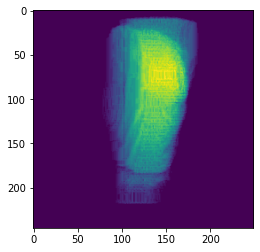

In [107]:
plt.imshow(depth[:,100])

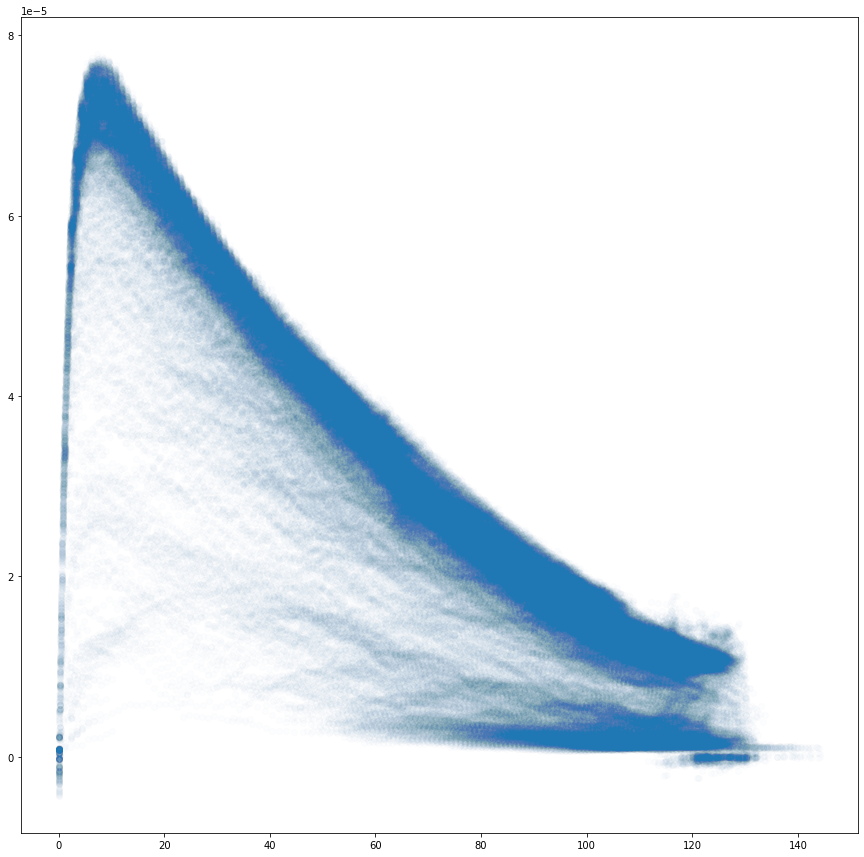

In [87]:
wed = np.cumsum(out/1000, axis=1)
fig, ax = plt.subplots(1,1, figsize=(15,15))
ax.plot(
    wed[bev!=0],
    out_d[bev!=0],
    'o',
    alpha=0.01,
)

In [192]:
img.TransformPhysicalPointToIndex(isocenter)

(102, 139, 109)

In [119]:
temp = out_d.swapaxes(1, 2).reshape((246*249, 246)).clip(min=0)
temp_mask = mask.swapaxes(1, 2).reshape((246*249, 246)).clip(min=0)
temp_depth = depth.swapaxes(1, 2).reshape((246*249, 246)).clip(min=0)
temp_dose = d.swapaxes(1, 2).reshape((246*249, 246)).clip(min=0)
temp_wed = wed.swapaxes(1,2).reshape((246*249, 246)).clip(min=0)
temp_bev = out_bev.swapaxes(1,2).reshape(temp.shape).sum(1)

ct2 = temp[temp_bev!=0]
dep2 = temp_depth[temp_bev!=0]
dose2 = temp_dose[temp_bev!=0]
wed2 = temp_wed[temp_bev!=0]

In [125]:
import torch

In [141]:
x = np.stack([ct2, dep2, wed2], axis=1)
y = dose2[:, None, ...]

x = torch.tensor(x).float()
y = torch.tensor(y).float()*1e5

In [135]:
x.shape, y.shape

(torch.Size([2080, 3, 246]), torch.Size([2080, 1, 246]))

In [136]:
x.dtype

torch.float32

In [162]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# ----------------------------------------------------------------------
# 1. Model Definition
# ----------------------------------------------------------------------
class Conv1DModel(nn.Module):
    def __init__(self, in_channels: int = 3, out_channels: int = 1):
        super().__init__()
        # Conv1d layers with padding=1 maintain sequence length (246)
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(32, out_channels, kernel_size=3, padding=1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Input shape:  (batch_size, 3, 246)
        # Output shape: (batch_size, 1, 246)
        return self.net(x)


# ----------------------------------------------------------------------
# 2. Data Preparation & Setup
# ----------------------------------------------------------------------
# Generate dummy tensors matching your dimensions
n_samples = 2080
n_channels = 3
seq_length = 246

x_data = x
y_data = y

# Create Dataset and DataLoader
batch_size = 32
dataset = TensorDataset(x_data, y_data)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Select computing device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialise model, loss criterion, and optimiser
model = Conv1DModel(in_channels=3, out_channels=1).to(device)
criterion = nn.MSELoss()
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)



In [163]:
epochs = 100

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    
    for batch_x, batch_y in dataloader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        # Reset gradients
        optimiser.zero_grad()
        
        # Forward pass
        predictions = model(batch_x)
        loss = criterion(predictions, batch_y)
        
        # Backward pass & optimisation
        loss.backward()
        optimiser.step()
        
        # Accumulate loss
        running_loss += loss.item() * batch_x.size(0)
        
    epoch_loss = running_loss / len(dataset)
    
    if epoch % 2 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{epochs:02d} | Mean Loss: {epoch_loss:.6f}")

Epoch 01/100 | Mean Loss: 2.872355
Epoch 02/100 | Mean Loss: 1.435534
Epoch 04/100 | Mean Loss: 0.872866
Epoch 06/100 | Mean Loss: 0.850674
Epoch 08/100 | Mean Loss: 0.828024
Epoch 10/100 | Mean Loss: 0.792445
Epoch 12/100 | Mean Loss: 0.801403
Epoch 14/100 | Mean Loss: 0.780403
Epoch 16/100 | Mean Loss: 0.767973
Epoch 18/100 | Mean Loss: 0.794188
Epoch 20/100 | Mean Loss: 0.809789
Epoch 22/100 | Mean Loss: 0.833606
Epoch 24/100 | Mean Loss: 0.784128
Epoch 26/100 | Mean Loss: 0.824701
Epoch 28/100 | Mean Loss: 0.806910
Epoch 30/100 | Mean Loss: 0.782226
Epoch 32/100 | Mean Loss: 0.788566
Epoch 34/100 | Mean Loss: 0.785300
Epoch 36/100 | Mean Loss: 0.809127
Epoch 38/100 | Mean Loss: 0.777622
Epoch 40/100 | Mean Loss: 0.765912
Epoch 42/100 | Mean Loss: 0.754148
Epoch 44/100 | Mean Loss: 0.757833
Epoch 46/100 | Mean Loss: 0.748715
Epoch 48/100 | Mean Loss: 0.765579
Epoch 50/100 | Mean Loss: 0.873367
Epoch 52/100 | Mean Loss: 0.789095
Epoch 54/100 | Mean Loss: 0.751225
Epoch 56/100 | Mean 

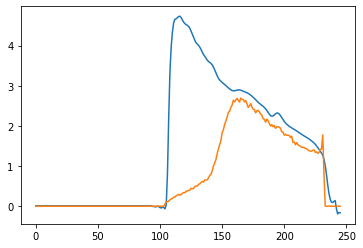

In [174]:
plt.plot(predictions[3,0].detach().cpu())
plt.plot(y[3,0].detach().cpu())

In [111]:
t2.shape

(2080, 246)

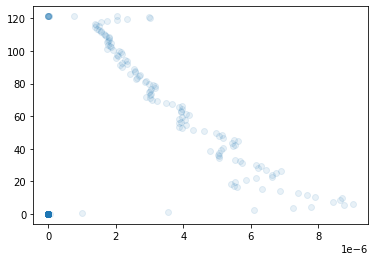

In [89]:
plt.plot(t2[0], w2[0], 'o', alpha=0.1)

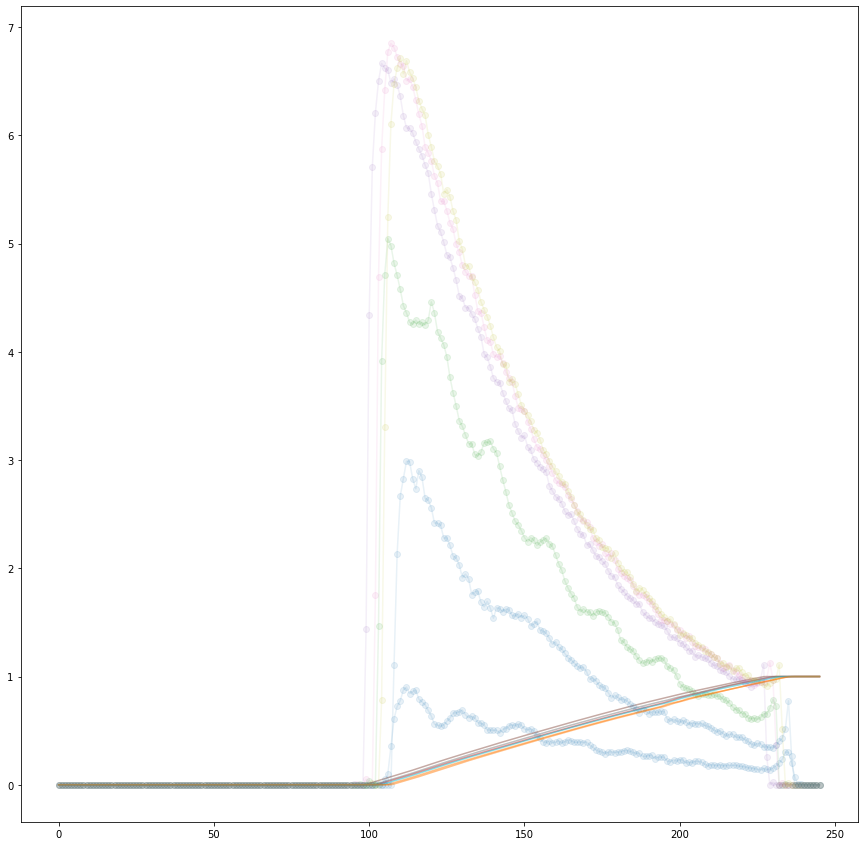

In [93]:
fig, ax = plt.subplots(1,1, figsize=(15,15))
for i in range(0,158,30):
    ax.plot(t2[i]*1e5, '-o', alpha=0.1)
    ax.plot(w2[i]/w2[i].max(), '-', alpha=0.5)

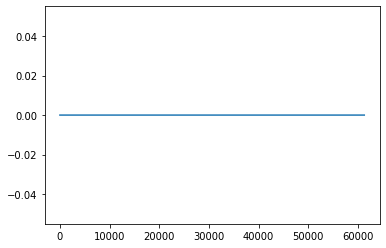

In [17]:
plt.plot(temp[0])

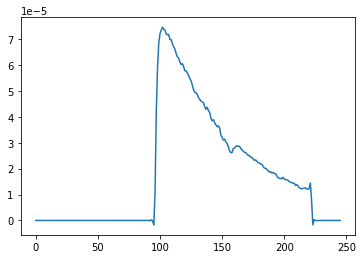

In [12]:
plt.plot(out_d[102, :, 109])

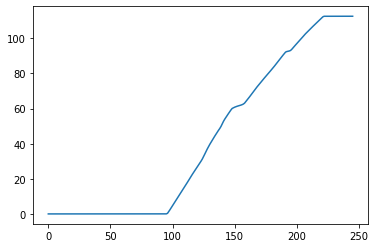

In [13]:
plt.plot(np.cumsum(out/1000, axis=1)[102, :, 109])
